In [1]:
import os
import sys
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
import numpy as np
import pprint
import networkx as nx
import statistics

if os.path.isdir("../data/"):
    os.chdir("../")

%load_ext autoreload
%autoreload 2

from src.plots_utils import get_plt_attr, get_politic_news_color_maps
from src.utils import *


rcParams, column_width, page_width, shorts_style, RV_style = get_plt_attr()
plt.rcParams.update(rcParams)

In [2]:
yt_nm_videos_2022 = pd.read_json("data/youtube/videos/news_videos_2022.jsonl", lines=True)
yt_nm_videos_2024 = pd.read_json("data/youtube/videos/news_videos_2024.jsonl", lines=True)
yt_pp_videos_2022 = pd.read_json("data/youtube/videos/pp_videos_2022.jsonl", lines=True)
yt_pp_videos_2024 = pd.read_json("data/youtube/videos/pp_videos_2024.jsonl", lines=True)
for yt_df in [yt_nm_videos_2022, yt_nm_videos_2024, yt_pp_videos_2022, yt_pp_videos_2024]:
    yt_df['publishedAt'] = pd.to_datetime(yt_df['publishedAt'])

In [52]:
nm_name_standard_list = yt_nm_videos_2024['name_standard'].unique()

In [3]:
videoId2yt_type = dict(zip(yt_nm_videos_2022['videoId'], ["Short"  if e==True else "RV" for e in list(yt_nm_videos_2022['isShort'])]))
videoId2yt_type.update(dict(zip(yt_nm_videos_2024['videoId'], 
                                ["Short"  if e==True else "RV" for e in list(yt_nm_videos_2024['isShort'])])))
videoId2yt_type.update(dict(zip(yt_pp_videos_2022['videoId'], 
                                ["Short"  if e==True else "RV" for e in list(yt_pp_videos_2022['isShort'])])))
videoId2yt_type.update(dict(zip(yt_pp_videos_2024['videoId'], 
                                ["Short"  if e==True else "RV" for e in list(yt_pp_videos_2024['isShort'])])))

In [4]:
yt_videoId2publishedAt = dict(zip(yt_nm_videos_2022['videoId'], yt_nm_videos_2022['publishedAt']))
yt_videoId2publishedAt.update(dict(zip(yt_nm_videos_2024['videoId'], yt_nm_videos_2024['publishedAt'])))
yt_videoId2publishedAt.update(dict(zip(yt_pp_videos_2022['videoId'], yt_pp_videos_2022['publishedAt'])))
yt_videoId2publishedAt.update(dict(zip(yt_pp_videos_2024['videoId'], yt_pp_videos_2024['publishedAt'])))

In [5]:
tt_nm_videos_2022 = pd.read_json("data/tiktok/videos/news_videos_2022.jsonl", lines=True)
tt_nm_videos_2024 = pd.read_json("data/tiktok/videos/news_videos_2024.jsonl", lines=True)
tt_pp_videos_2022 = pd.read_json("data/tiktok/videos/pp_videos_2022.jsonl", lines=True)
tt_pp_videos_2024 = pd.read_json("data/tiktok/videos/pp_videos_2024.jsonl", lines=True)
for tt_df in [tt_nm_videos_2022, tt_nm_videos_2024, tt_pp_videos_2022, tt_pp_videos_2024]:
    tt_df.rename(columns={'id':'videoId', 'voice_to_text':'transcript','create_time':'publishedAt'}, inplace=True)
    tt_df['videoId'] = tt_df['videoId'].apply(str)
    tt_df['publishedAt'] = pd.to_datetime(tt_df['publishedAt'])

In [6]:
tt_videoId2publishedAt = dict(zip(tt_nm_videos_2022['videoId'], tt_nm_videos_2022['publishedAt']))
tt_videoId2publishedAt.update(dict(zip(tt_nm_videos_2024['videoId'], tt_nm_videos_2024['publishedAt'])))
tt_videoId2publishedAt.update(dict(zip(tt_pp_videos_2022['videoId'], tt_pp_videos_2022['publishedAt'])))
tt_videoId2publishedAt.update(dict(zip(tt_pp_videos_2024['videoId'], tt_pp_videos_2024['publishedAt'])))

In [7]:
def load_gs(filepath):
    gs_folder = filepath
    filenames = [filename for filename in os.listdir(gs_folder) if filename[-3:] == '.gv']
    gs = dict()
    for filename in filenames:
        standard_name = filename.split('_')[0]
        gs[standard_name] = nx.nx_agraph.read_dot(gs_folder+filename)
    return gs

In [68]:
gs_pp_only = load_gs('data/networks/pp_only_2024/')
gs_news_only = load_gs('data/networks/news_only_2024/')
gs_diff = load_gs('data/networks/diff_2024/')
gs_parties = load_gs('data/networks/parties_2024/')

In [9]:
def get_platform_from_videoId(videoid):
    if len(videoid) == 11: return 'yt'
    else: return 'tt'

In [10]:
# I do remember that for some cases I had to take it when it's larger than 1 but now it seems absurd to do so because when there is only one link it disappears
def get_video_matches(row, name_standard, gs, platform = 'both', yt_type = 'both'):
    try:
        videoId = row.videoId.values[0]
    except AttributeError as e:
        videoId = row.videoId
    if videoId in gs[name_standard]:
        if len(list(gs[name_standard][videoId])) > 0:
            if platform == 'both':
                if yt_type == 'both':
                    return list([v_id for v_id in gs[name_standard][videoId]])
                else:
                    return list([v_id for v_id in gs[name_standard][videoId] if videoId2yt_type[v_id] == yt_type])
            return list([v_id for v_id in gs[name_standard][videoId] if get_platform_from_videoId(v_id) == platform]) 
        else :
            return ''
    else: 
        return ''

In [57]:
pp_name_standard_list = ['Gabriel Attal', 'RN', 'LR', 'Mathilde Panot', 'MoDem', 'Nicolas Dupont-Aignan', 'Rima Hassan', 'François Asselineau', 
                          'LFI', 'EELV', 'Florian Philippot', 'PCF',  'RE', 'PS', 'LO',
                      'UPR',
                          'Marine Le Pen', 'Éric Zemmour', 'Emmanuel Macron', 'PP', 'UDI', 'LP', 'Jean-Luc Mélenchon', 
                          'Manuel Bompard', 'François Ruffin', 'Manon Aubry', 'Jordan Bardella', 'NPA', 'Marion Maréchal']

In [12]:
def count_distinct_cuts(row, name_standard, gs, yt_type='both'):
    """Number of distinct underlying clips an RV was cut into,
    collapsing same-clip nodes that are linked in the graph."""
    try:
        videoId = row.videoId.values[0]
    except AttributeError:
        videoId = row.videoId

    g = gs[name_standard]
    if videoId not in g:
        return 0

    nbrs = list(g[videoId])
    if yt_type != 'both':
        # keep only YT neighbors of the requested type, plus all TT nodes
        nbrs = [v for v in nbrs
                if get_platform_from_videoId(v) != 'yt' or videoId2yt_type[v] == yt_type]
    if len(nbrs) == 0:
        return 0

    sub = g.subgraph(nbrs)
    if sub.is_directed():
        sub = sub.to_undirected()
    return nx.number_connected_components(sub)

In [56]:
def create_metrics_df(df_yt, df_tt, gs, name_standard_list, FILL_NA = False):
    metrics = dict()
    all_elapsed_times = list()
    
    for name_standard in name_standard_list:
        gs_name = gs[name_standard]
        density = nx.density(gs_name)
        transitivity = nx.transitivity(gs_name)
        elapsed_times = [float(e[2]['elapsed_time_sec']) for e in list(gs_name.edges(data=True))]
        if len(elapsed_times) > 0:
            mean_elapsed_time = np.mean(elapsed_times)
            all_elapsed_times = all_elapsed_times + elapsed_times
            std_elapsed_time = np.std(elapsed_times)
        else:
            mean_elapsed_time = np.nan
            std_elapsed_time = np.nan
        metrics[name_standard] = {
            #'density':density, 
            #'transitivity':transitivity, 
            'mean_elapsed_time':mean_elapsed_time, 
            'std_elapsed_time':std_elapsed_time
        }

        df_yt_name = df_yt[(df_yt.name_standard == name_standard)][['videoId', 'publishedAt', 'isShort']]
        df_yt_name['type'] = df_yt_name['isShort'].apply(lambda x: 'Short' if x else 'RV')
        df_yt_name['publishedAt'] = df_yt_name['publishedAt'].dt.tz_localize(None)

        df_yt_name['matches_video_yt'] = df_yt_name.apply(
            get_video_matches, name_standard=name_standard, gs=gs, platform = 'yt', axis=1)
        df_yt_name['matches_video_tt'] = df_yt_name.apply(
            get_video_matches, name_standard=name_standard, gs=gs, platform = 'tt', axis=1)
        df_yt_name['matches_video_both'] = df_yt_name.apply(
            get_video_matches, name_standard=name_standard, gs=gs, platform = 'both', axis=1) 
        df_yt_name['n_matches'] = df_yt_name['matches_video_both'].apply(len)
    
        df_yt_name['n_distinct_cuts'] = df_yt_name.apply(
            count_distinct_cuts, name_standard=name_standard, gs=gs, axis=1)

        df_tt_name = df_tt[df_tt.name_standard == name_standard][['videoId', 'publishedAt']]
        df_tt_name['matches_RV'] = df_tt_name.apply(
            get_video_matches, name_standard=name_standard, gs = gs, yt_type = 'RV', axis=1)
        df_tt_name['matches_Shorts'] = df_tt_name.apply(
            get_video_matches, name_standard=name_standard, gs = gs, yt_type = 'Short', axis=1)
        df_tt_name['matches_all'] = df_tt_name.apply(
            get_video_matches, name_standard=name_standard, gs = gs, axis=1)
        
        df_tt_name['type'] = 'tiktok'
        df_tt_name['publishedAt'] = df_tt_name['publishedAt'].dt.tz_localize(None)

        rvs = df_yt_name[df_yt_name['type'] == 'RV']
        shorts = df_yt_name[df_yt_name['type'] == 'Short']

        metrics[name_standard]['n_videos'] = len(df_tt_name) + len(df_yt_name)
        metrics[name_standard]['% Shorts'] = len(shorts)/(len(df_tt_name) + len(df_yt_name))
        metrics[name_standard]['% tiktoks'] = len(df_tt_name)/(len(df_tt_name) + len(df_yt_name))
        
        metrics[name_standard]['RV_got_cut_rate'] = len(rvs[rvs['n_distinct_cuts'] > 0]) / len(rvs)
        metrics[name_standard]['RV_mean_n_cuts_prev'] = np.mean(df_yt_name[df_yt_name['type'] == 'RV']['n_matches'])
        metrics[name_standard]['RV_mean_n_cuts'] = np.mean(rvs[rvs['n_distinct_cuts'] > 0]['n_distinct_cuts'])

        cut_rvs = rvs[rvs['n_distinct_cuts'] > 0]
        if len(cut_rvs) > 0:
            metrics[name_standard]['RV_multi_cut_rate'] = \
                len(cut_rvs[cut_rvs['n_distinct_cuts'] > 1]) / len(cut_rvs)
        else:
            metrics[name_standard]['RV_multi_cut_rate'] = np.nan
        
        if len(df_tt_name) > 0:
            # coverage harmonic mean between percentage of tt who matches and percentage of shorts who matches
            
            tt_match_rate = len(df_tt_name[df_tt_name['matches_Shorts'] != '']) / len(df_tt_name)
            
            if len(shorts) > 0:
                yt_match_rate = len(shorts[shorts['matches_video_tt'] != '']) / len(shorts)
            else :
                yt_match_rate = 0
            
            metrics[name_standard]['coverage'] = statistics.harmonic_mean([tt_match_rate, yt_match_rate])
        else:
            metrics[name_standard]['coverage'] = 0
        
    if FILL_NA:        
        for name_standard in name_standard_list:
            if np.isnan(metrics[name_standard]['mean_elapsed_time']):
                metrics[name_standard]['mean_elapsed_time'] = np.median(all_elapsed_times)
                metrics[name_standard]['std_elapsed_time'] = np.std(all_elapsed_times)
    return metrics

In [59]:
metrics = create_metrics_df(df_yt = yt_pp_videos_2024, df_tt = tt_pp_videos_2024, gs = gs_pp_only, 
                            name_standard_list=pp_name_standard_list, FILL_NA = False)


In [60]:
metrics_df = pd.DataFrame.from_dict(metrics).T
metrics_df_nona = metrics_df.dropna()

metrics_nona = {k:v for k,v in metrics.items() if not np.isnan(v['mean_elapsed_time'])}

In [61]:
metrics_array = np.array(
    [list(m.values()) for m in metrics_nona.values()],
    dtype=np.float64
)

In [62]:
metrics_names = list(metrics_nona.values())[0].keys()
print(metrics_names)

dict_keys(['mean_elapsed_time', 'std_elapsed_time', 'n_videos', '% Shorts', '% tiktoks', 'RV_got_cut_rate', 'RV_mean_n_cuts_prev', 'RV_mean_n_cuts', 'RV_multi_cut_rate', 'coverage'])


In [63]:
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler

X_scaled = StandardScaler().fit_transform(metrics_array)
for n_components in range(1, 6):
    
    pca = PCA(n_components=n_components)
    X_reduced = pca.fit_transform(X_scaled)
    print(pca.explained_variance_ratio_)
print("Reduced shape:", X_reduced.shape)
print("Explained variance ratio:", pca.explained_variance_ratio_)
print("Components:"), 
for m, c1, c2 in zip(metrics_names, pca.components_[0], pca.components_[1]):
    print(f"{m:>40} {c1:.2f} {c2:.2f}")

[0.35483673]
[0.35483673 0.21078732]
[0.35483673 0.21078732 0.20002582]
[0.35483673 0.21078732 0.20002582 0.09006232]
[0.35483673 0.21078732 0.20002582 0.09006232 0.05604173]
Reduced shape: (25, 5)
Explained variance ratio: [0.35483673 0.21078732 0.20002582 0.09006232 0.05604173]
Components:
                       mean_elapsed_time -0.24 0.44
                        std_elapsed_time -0.11 0.28
                                n_videos 0.14 0.17
                                % Shorts 0.41 -0.02
                               % tiktoks 0.09 0.29
                         RV_got_cut_rate 0.48 -0.10
                     RV_mean_n_cuts_prev 0.50 -0.02
                          RV_mean_n_cuts 0.24 0.48
                       RV_multi_cut_rate 0.15 0.59
                                coverage 0.41 -0.13


In [64]:
party_colors = {
    # Far Left — dark reds
    'LO':   '#5C0002', 'NPA':  '#8B0000',
    # Left — reds / warm
    'LFI':  '#C1121F', 'PCF':  '#E01E37', 
    'EELV': '#52B788',# greens for ecologists
    'PS':   '#F94144', 'PP':   '#2D6A4F',
    
    # Center — orange / amber / yellow
    'RE':   '#F9A825', 'MoDem':'#FF7B00', 'UDI':  '#FFD166', 'HOR':  '#F4A261',
    # Right — light-to-mid blues
    'UPR':  '#90E0EF', 'LR':   '#457B9D', 'DLF':  '#0096C7',
    # Far Right — dark blues / navy
    'RN':   '#1D3557', 'LP':   '#023E8A', 'REC':  '#03045E',
}

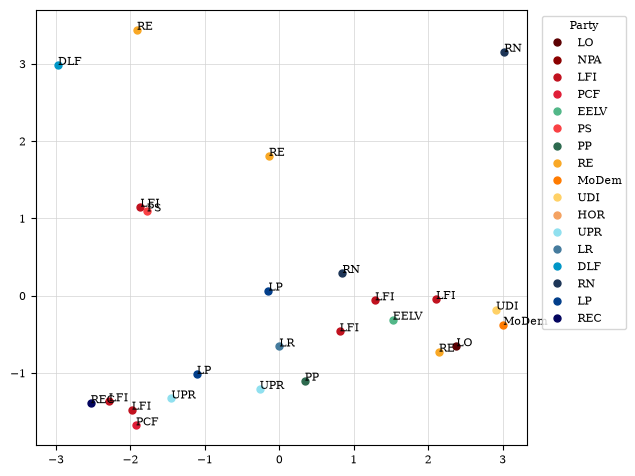

In [65]:
fig, ax = plt.subplots()
for X, standard_name in zip(X_reduced, pp_name_standard_list):
    ax.plot(X[0], X[1], ".", color=party_colors[get_politician2party()[standard_name]], markersize=10)
    ax.text(X[0], X[1], get_politician2party()[standard_name])
from matplotlib.lines import Line2D

handles = [
    Line2D([0], [0], marker='.', linestyle='',
           color=color, markersize=10, label=party)
    for party, color in party_colors.items()
]
plt.grid(color='lightgrey', linestyle='-', linewidth=0.5)
x0, x1 = ax.get_xlim()
y0, y1 = ax.get_xlim()

#plt.plot([x0, x1], [0, 0], color='grey')
#plt.plot([0, 0], [y0, y1], color='grey')
#ax.set_xlim(x0, x1)
#ax.set_ylim(y0, y1)
ax.legend(handles=handles, title='Party',
          bbox_to_anchor=(1.02, 1), loc='upper left',
          ncol=1, fontsize=8)
fig.tight_layout()

# Heatmap

# TODO
- ajouter le fait que certaine RV on été cut plus d'une fois


/var/folders/s8/86mtzm812zdfvh1cgg7lh2wh0000gp/T/ipykernel_4021/2774598778.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


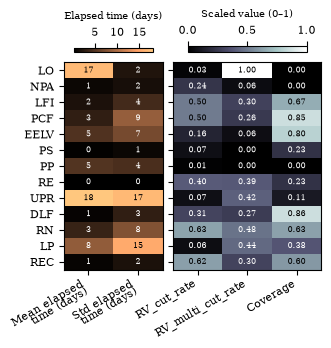

In [66]:
annotate = True
cmap_time = 'copper'   
cmap_rate = 'bone'

df = metrics_df_nona.copy()

day_metrics  = ['mean_elapsed_time', 'std_elapsed_time']
rate_metrics = ['RV_got_cut_rate', 'RV_multi_cut_rate', 'coverage']
day_labels   = ['Mean elapsed\ntime (days)', 'Std elapsed\ntime (days)']
rate_labels  = ['RV_cut_rate', 'RV_multi_cut_rate', 'Coverage']

# --- Aggregate to party level (mean of each metric) ---------
df['_party'] = [get_politician2party()[n] for n in df.index]
df = df.groupby('_party')[day_metrics + rate_metrics].mean()

party_order = [p for p in party_colors if p in df.index]
df = df.loc[party_order]
parties = list(df.index)
n = len(parties)

# --- Days: seconds -> days -----------------------------------
day_raw = df[day_metrics].to_numpy() / 86400.0
vmin_d, vmax_d = np.nanmin(day_raw), np.nanmax(day_raw)   # shared day scale

# --- Rates: min-max the count column onto 0-1 ---------------
df_rate = df[rate_metrics].copy()
#lo, hi = df_rate['RV_mean_n_cuts'].min(), df_rate['RV_mean_n_cuts'].max()
#df_rate['RV_mean_n_cuts'] = (df_rate['RV_mean_n_cuts'] - lo) / (hi - lo) if hi > lo else 0.0
rate_data = df_rate[rate_metrics].to_numpy()

# --- Plot: two panels sharing y -----------------------------
fig, (axL, axR) = plt.subplots(
    1, 2, figsize=(column_width, column_width), sharey=True,
    gridspec_kw={'width_ratios': [len(day_metrics), len(rate_metrics)], 'wspace': 0.08}
)

# LEFT: days, coloured on shared day scale, annotated with real days
imL = axL.imshow(day_raw, aspect='auto', cmap=cmap_time, vmin=vmin_d, vmax=vmax_d)
axL.set_xticks(np.arange(len(day_metrics)))
axL.set_xticklabels(day_labels, rotation=30, ha='right', linespacing=0.75)
axL.set_yticks(np.arange(n))
axL.set_yticklabels(parties, fontsize=8)

# RIGHT: rates 0-1
imR = axR.imshow(rate_data, aspect='auto', cmap=cmap_rate, vmin=0, vmax=1)
axR.set_xticks(np.arange(len(rate_metrics)))
axR.set_xticklabels(rate_labels, rotation=30, ha='right', linespacing=0.75)

if annotate:
    mid_d = (vmin_d + vmax_d) / 2
    for i in range(n):
        for j in range(len(day_metrics)):
            v = day_raw[i, j]
            axL.text(j, i, f'{v:.0f}', ha='center', va='center', fontsize=6,
                     color='white' if v < mid_d else 'black')
        for j in range(len(rate_metrics)):
            v = rate_data[i, j]
            axR.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=6,
                     color='white' if v < 0.5 else 'black')

cbarL = fig.colorbar(imL, ax=axL, shrink=0.8, location='top', pad=0.04)
cbarL.ax.set_title('Elapsed time (days)', fontsize=7, pad=6)

cbarR = fig.colorbar(imR, ax=axR, shrink=0.8, location='top', pad=0.04)
cbarR.ax.set_title('Scaled value (0–1)', fontsize=7, pad=6)

plt.tight_layout()
fig.savefig('Figures/heatmap_upload_patterns.pdf', bbox_inches='tight')
fig.savefig('../00_ARTICLES/69d66ccf1cded16fd8f7b0c2/Figures/heatmap_upload_patterns.pdf', bbox_inches='tight')
plt.show()


# NM

In [69]:
metrics_nm = create_metrics_df(df_yt = yt_nm_videos_2024, df_tt = tt_nm_videos_2024, gs = gs_news_only, 
                            name_standard_list=nm_name_standard_list, FILL_NA = False)

In [71]:
metrics_nm_df = pd.DataFrame.from_dict(metrics_nm).T
metrics_nm_df_nona = metrics_nm_df.dropna()

metrics_nm_df_nona = {k:v for k,v in metrics_nm.items() if not np.isnan(v['mean_elapsed_time'])}

In [75]:
metrics_nm_df_nona

{'Le Point': {'mean_elapsed_time': np.float64(687287.9857142858),
  'std_elapsed_time': np.float64(1625174.3551674737),
  'n_videos': 1220,
  '% Shorts': 0.012295081967213115,
  '% tiktoks': 0.10081967213114754,
  'RV_got_cut_rate': 0.11275415896487985,
  'RV_mean_n_cuts_prev': np.float64(0.12014787430683918),
  'RV_mean_n_cuts': np.float64(1.0163934426229508),
  'RV_multi_cut_rate': 0.01639344262295082,
  'coverage': 0.7486631016042781},
 'AFP': {'mean_elapsed_time': np.float64(431605.5789473684),
  'std_elapsed_time': np.float64(1482639.7363126082),
  'n_videos': 1853,
  '% Shorts': 0.1305990286022666,
  '% tiktoks': 0.030221262817053427,
  'RV_got_cut_rate': 0.06495176848874598,
  'RV_mean_n_cuts_prev': np.float64(0.06816720257234726),
  'RV_mean_n_cuts': np.float64(1.0396039603960396),
  'RV_multi_cut_rate': 0.0297029702970297,
  'coverage': 0.3826530612244898},
 'Le Média': {'mean_elapsed_time': np.float64(192650.75),
  'std_elapsed_time': np.float64(289303.511377638),
  'n_videos

/var/folders/s8/86mtzm812zdfvh1cgg7lh2wh0000gp/T/ipykernel_4021/1451424574.py:67: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


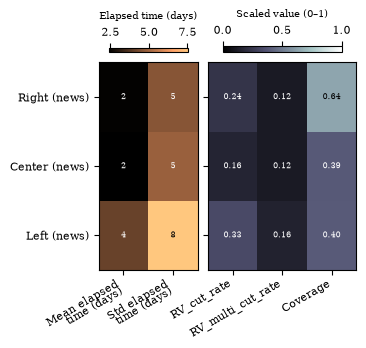

In [77]:
annotate = True
cmap_time = 'copper'   
cmap_rate = 'bone'

df = metrics_nm_df.copy()

day_metrics  = ['mean_elapsed_time', 'std_elapsed_time']
rate_metrics = ['RV_got_cut_rate', 'RV_multi_cut_rate', 'coverage']
day_labels   = ['Mean elapsed\ntime (days)', 'Std elapsed\ntime (days)']
rate_labels  = ['RV_cut_rate', 'RV_multi_cut_rate', 'Coverage']

# --- Aggregate to orientation level (mean of each metric) ---------
df['_orientation'] = [get_news_channel_orientation()[n] for n in df.index]
df = df.groupby('_orientation')[day_metrics + rate_metrics].mean()

orientation_order = ['Right (news)', 'Center (news)', 'Left (news)']
df = df.loc[orientation_order]
orientations = list(df.index)
n = len(orientations)

# --- Days: seconds -> days -----------------------------------
day_raw = df[day_metrics].to_numpy() / 86400.0
vmin_d, vmax_d = np.nanmin(day_raw), np.nanmax(day_raw)   # shared day scale

# --- Rates: min-max the count column onto 0-1 ---------------
df_rate = df[rate_metrics].copy()
#lo, hi = df_rate['RV_mean_n_cuts'].min(), df_rate['RV_mean_n_cuts'].max()
#df_rate['RV_mean_n_cuts'] = (df_rate['RV_mean_n_cuts'] - lo) / (hi - lo) if hi > lo else 0.0
rate_data = df_rate[rate_metrics].to_numpy()

# --- Plot: two panels sharing y -----------------------------
fig, (axL, axR) = plt.subplots(
    1, 2, figsize=(column_width, column_width), sharey=True,
    gridspec_kw={'width_ratios': [len(day_metrics), len(rate_metrics)], 'wspace': 0.08}
)

# LEFT: days, coloured on shared day scale, annotated with real days
imL = axL.imshow(day_raw, aspect='auto', cmap=cmap_time, vmin=vmin_d, vmax=vmax_d)
axL.set_xticks(np.arange(len(day_metrics)))
axL.set_xticklabels(day_labels, rotation=30, ha='right', linespacing=0.75)
axL.set_yticks(np.arange(n))
axL.set_yticklabels(orientations, fontsize=8)

# RIGHT: rates 0-1
imR = axR.imshow(rate_data, aspect='auto', cmap=cmap_rate, vmin=0, vmax=1)
axR.set_xticks(np.arange(len(rate_metrics)))
axR.set_xticklabels(rate_labels, rotation=30, ha='right', linespacing=0.75)

if annotate:
    mid_d = (vmin_d + vmax_d) / 2
    for i in range(n):
        for j in range(len(day_metrics)):
            v = day_raw[i, j]
            axL.text(j, i, f'{v:.0f}', ha='center', va='center', fontsize=6,
                     color='white' if v < mid_d else 'black')
        for j in range(len(rate_metrics)):
            v = rate_data[i, j]
            axR.text(j, i, f'{v:.2f}', ha='center', va='center', fontsize=6,
                     color='white' if v < 0.5 else 'black')

cbarL = fig.colorbar(imL, ax=axL, shrink=0.8, location='top', pad=0.04)
cbarL.ax.set_title('Elapsed time (days)', fontsize=7, pad=6)

cbarR = fig.colorbar(imR, ax=axR, shrink=0.8, location='top', pad=0.04)
cbarR.ax.set_title('Scaled value (0–1)', fontsize=7, pad=6)

plt.tight_layout()
#fig.savefig('Figures/heatmap_upload_patterns.pdf', bbox_inches='tight')
#fig.savefig('../00_ARTICLES/69d66ccf1cded16fd8f7b0c2/Figures/heatmap_upload_patterns.pdf', bbox_inches='tight')
plt.show()
